In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt 
from data_processing.processing.figure_of_merit import fit_fom, FOM, gaussian, n_sigma_classifier
from data_processing.reporting.plotting import plot_fom, plot_scatter, plot_classification_with_grouping
from scipy.optimize import curve_fit

In [2]:
# Set up experiment
def fit_gauss(counts, bins):
    params, cov = curve_fit(gaussian, bins[:-1], counts)
    return abs(params), cov

EXP_NAME = "echem_exp"
ROOT = Path("../sample_datasets/.temp_echem/")
AMPLITUDES_PATH = ROOT / "amplitudes.csv"
PSD_PATH =  ROOT / "psd.csv"

psd = pd.read_csv(PSD_PATH, header=None)
amplitudes = pd.read_csv(AMPLITUDES_PATH, header=None)
psd_report = pd.concat([psd, amplitudes], axis=1)
psd_report.columns = ["tail / total", "amplitude"]

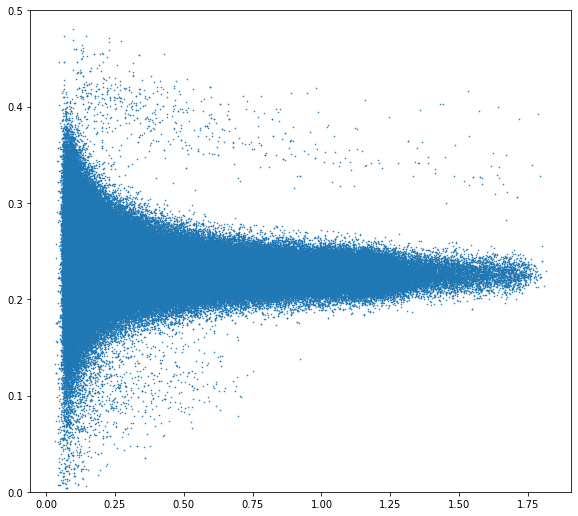

In [3]:
# Plot PSD
fig, ax = plot_scatter(psd_report["amplitude"], psd_report["tail / total"])
ax.set_ylim(0,0.5)
fig.set_figheight(7)
fig.set_figwidth(8)

## Gaussian Fitting

This section is to find the gamma band gaussian. 

Parameters that may need to be adjusted to fit better...
- `cutoff_voltage`
- `b1`: psd bounds to tell where to look for max values of amplitudes
- `b2`: psd bounds to tell where to look for min values of amplitudes
- `curv_fit_params`: $(\mu, \sigma, A)$ to guide curve fitting


**Assumption:** Gaussians are modified until acceptable. That is, if the plot in [Bounding Box](#Bounding-Box) does not overlap with the gamma band too obviously. (TO VERIFY)

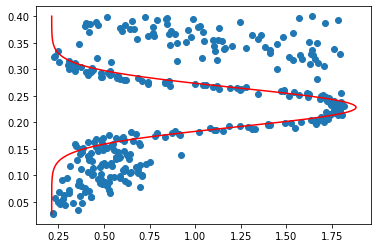

In [4]:
cutoff_voltage = 0.213 # Adjust cutoff voltage
b1 = (0.0, 0.4) # limit scanning window to find max
b2 = (0.22, 0.23) # limit scanning window to find min 
curv_fit_params = (0.25,0.037,1.67) # To adjust curve fitting 


psd_report = psd_report[psd_report["amplitude"] >= cutoff_voltage]

# Find maxs / "outlines" gamma band 
rounded_psd = psd_report.copy()
rounded_psd["tail / total"] = rounded_psd["tail / total"].apply(lambda x: round(x, 3))
scanning_window = rounded_psd[rounded_psd["tail / total"].between(*b1)]
grouped_max = scanning_window.groupby(["tail / total"], as_index=False)["amplitude"].max()

# Find average mininum voltage to get DC offset
rounded_2 = psd_report.copy()
rounded_2["tail / total"] = rounded_2["tail / total"].apply(lambda x: round(x, 2))
scanning_window_min = rounded_2[rounded_2["tail / total"].between(*b2)]
grouped_min = scanning_window_min.groupby(["tail / total"], as_index=False)["amplitude"].min()
avg_min = grouped_min.mean()["amplitude"]

# Fitting cutoff
params, cov = curve_fit(
    gaussian,
    grouped_max["tail / total"], 
    grouped_max["amplitude"] + avg_min,
    bounds=((0.20,0.01,1.3), curv_fit_params) 
)

# Plotting cutoff
plt.scatter(grouped_max["amplitude"], grouped_max["tail / total"])
plt.plot(gaussian(grouped_max["tail / total"], *params) + avg_min, grouped_max["tail / total"], 'r-')
plt.show()

# Bounding Box

Find the bounding box with `n` sigma tolerance. Change `n` if necessary.



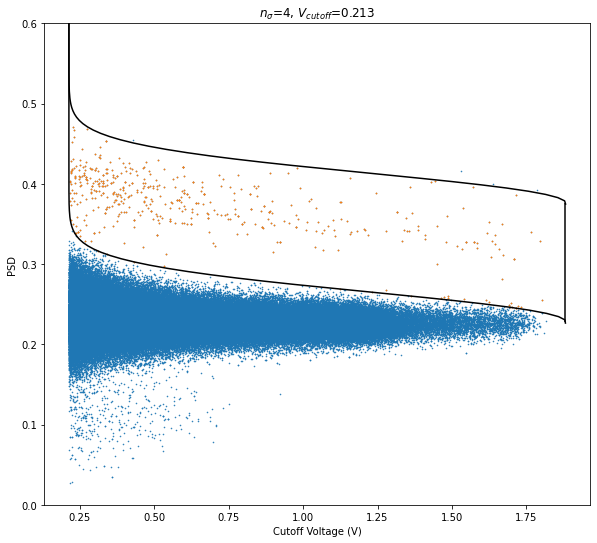

In [5]:
n = 4 # n value to be multiplied to sigma

p = np.linspace(-1,1,500)
mu, sigma, A = params

# Find the gamma distribution then move the mean by n_sigma
gamma = gaussian(psd_report["tail / total"], *params) + avg_min
gate = gaussian(psd_report["tail / total"], mu + n * sigma, sigma, A) + avg_min


# Trick to allow correct filtering
range_filt = psd_report["tail / total"] <= psd_report["tail / total"][gate.idxmax()]
gate[range_filt] = gate.max()


# Find neutrons in counting window below gate and above gamma
neutrons = psd_report[psd_report["amplitude"].between(
    gamma, gate
)]

neutrons = neutrons.loc[psd_report["tail / total"] >= mu]


# Plot classification
fig, ax = plot_scatter(psd_report["amplitude"], psd_report["tail / total"])
ax.scatter(neutrons["amplitude"], neutrons["tail / total"], s=0.5)

# Plotting bounding box
gamma_gauss = gaussian(p, mu, sigma, A) + avg_min
gate_gauss = gaussian(p, mu + n * sigma, sigma, A) + avg_min
ax.plot(gamma_gauss[gamma_gauss.argmax():], p[gamma_gauss.argmax():], 'k-')
ax.plot(gate_gauss[gate_gauss.argmax():], p[gate_gauss.argmax():], 'k-')
ax.vlines(gamma_gauss.max(), mu, mu + n*sigma, "k")

ax.set_ylim(0,0.6)
fig.set_figheight(7)
fig.set_figwidth(8)
ax.set_xlabel("Cutoff Voltage (V)")
ax.set_ylabel("PSD")
ax.set_title(f"$n_\sigma$={n}, $V_{{cutoff}}$={cutoff_voltage}")
plt.show()

# FOM

Here we fit the two histograms to Gaussian distributions and calculate the FOM.

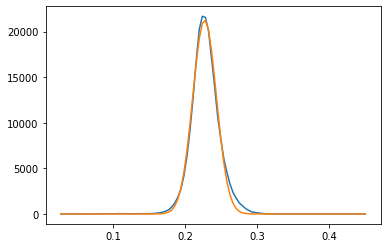

In [6]:
n_bins = 100
gammas = psd_report.copy()
gammas = gammas.drop(neutrons.index)
gamma_counts, gamma_bins = np.histogram(gammas["tail / total"], n_bins)
plt.plot(gamma_bins[:-1], gamma_counts)

gamma_params, _ = curve_fit(
    gaussian,
    gamma_bins[:-1], 
    gamma_counts,
    bounds=((0.20,0.001,1),(0.3,0.1,10e5))
)
plt.plot(gamma_bins[:-1], gaussian(gamma_bins[:-1], *gamma_params))
plt.show()

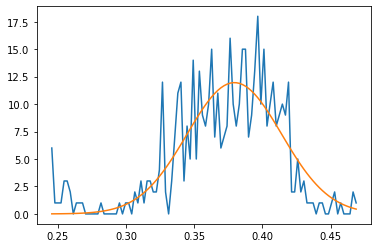

In [7]:
neutron_counts, neutron_bins = np.histogram(neutrons["tail / total"], n_bins)
plt.plot(neutron_bins[:-1], neutron_counts)

neutron_params, _ = fit_gauss(neutron_counts, neutron_bins)
plt.plot(neutron_bins[:-1], gaussian(neutron_bins[:-1], *neutron_params))
plt.show()

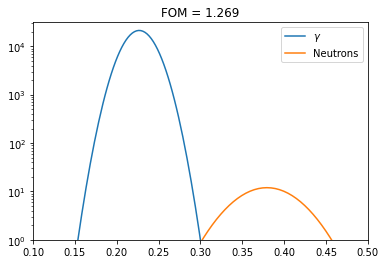

In [8]:
psd_range = np.linspace(0,0.5,200)

plt.plot(
    psd_range, gaussian(psd_range, *gamma_params), label="$\gamma$"
)

plt.plot(
    psd_range, gaussian(psd_range, *neutron_params), label="Neutrons"
)

plt.legend()
plt.yscale("log")
plt.xlim(0.1,0.5)
plt.ylim(1, gamma_params[-1] + 1e4)
plt.title(f"FOM = {FOM(*neutron_params[:-1], *gamma_params[:-1]):.3f}")
plt.show()